# Polynomial Regression 

Linear Regression finds the correlation between the dependent variable ( or target variable ) and independent variables ( or features ). In short, it is a linear model to fit the data linearly. But it fails to fit and catch the pattern in non-linear data. 

Let’s first apply Linear Regression on non-linear data to understand the need for Polynomial Regression. The Linear Regression model used in this article is imported from sklearn.

In [9]:
# Importing libraries
 
import numpy as np

import math
 
import pandas as pd
 
from sklearn.model_selection import train_test_split
 
import matplotlib.pyplot as plt
 
from sklearn.linear_model import LinearRegression

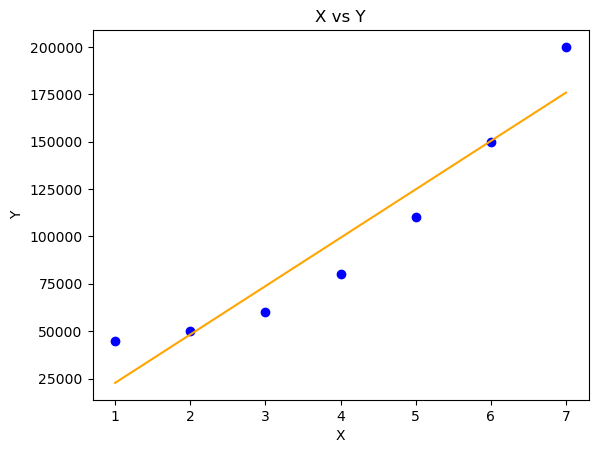

In [5]:
# driver code
 
def main() :
     
    # Create dataset
     
    X = np.array( [ [1], [2], [3], [4], [5], [6], [7] ] )
     
    Y = np.array( [ 45000, 50000, 60000, 80000, 110000, 150000, 200000 ] )
     
    # Model training
     
    model = LinearRegression()
 
    model.fit( X, Y )
     
    # Prediction
 
    Y_pred = model.predict( X )
     
    # Visualization 
     
    plt.scatter( X, Y, color = 'blue' )
     
    plt.plot( X, Y_pred, color = 'orange' )
     
    plt.title( 'X vs Y' )
     
    plt.xlabel( 'X' )
     
    plt.ylabel( 'Y' )
     
    plt.show()
     
     
if __name__ == "__main__" : 
     
    main()

As shown in the output visualization, Linear Regression even failed to fit the training data well ( or failed to decode the pattern in the Y with respect to X ). Because its hypothetical function is linear in nature and Y is a non-linear function of X in the data. 

For univariate linear regression : 

h( x ) = w * x

here,  x is the feature vector.

and w is the weight vector.

This problem is also called as underfitting. To overcome the underfitting, we introduce new features vectors just by adding power to the original feature vector.

For univariate polynomial regression : 
 
h( x ) = w1x + w2x2  + .... + wnxn 
 
here, w is the weight vector. 

where x2  is the derived feature from x. 

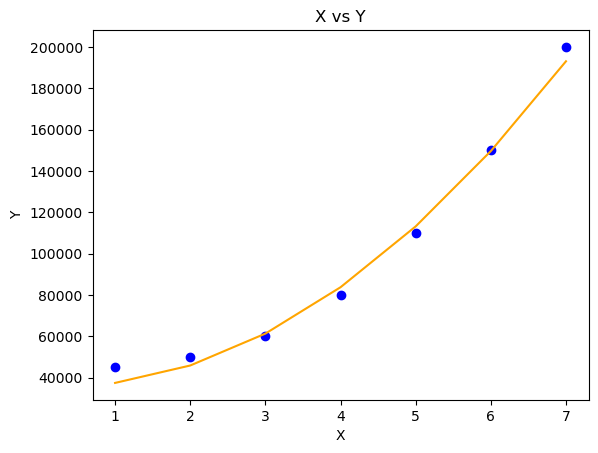

In [11]:
# Univariate Polynomial Regression

class PolynomialRegression():
    
    # Constructor to initialize degree, learning rate, and iterations
    def __init__(self, degree, learning_rate, iterations):
        self.degree = degree            # Degree of the polynomial (e.g., 2 for quadratic)
        self.learning_rate = learning_rate  # Learning rate for gradient descent
        self.iterations = iterations    # Number of iterations for gradient descent

    # Function to transform X into higher powers (polynomial transformation)
    def transform(self, X):
        # Initialize the transformed matrix with a column of ones (for the bias term w0)
        X_transform = np.ones((self.m, 1))
        
        # Loop through each power from 1 to degree and add corresponding columns
        for j in range(1, self.degree + 1):
            X_transform = np.append(X_transform, np.power(X, j).reshape(-1, 1), axis=1)
        
        return X_transform
    
    # Function to normalize the transformed input features (except the bias term)
    def normalize(self, X):
        # Make a copy of X to avoid modifying the original data
        X_normalized = X.copy()
        
        # Normalize each feature column (except the first one, which is the bias term)
        X_normalized[:, 1:] = (X_normalized[:, 1:] - np.mean(X_normalized[:, 1:], axis=0)) / np.std(X_normalized[:, 1:], axis=0)
        
        return X_normalized

    # Model training using gradient descent
    def fit(self, X, Y):
        self.X = X
        self.Y = Y
        
        # Get the number of data points (m) and the number of features (n)
        self.m, self.n = self.X.shape

        # Initialize weights (w) to zeros for each polynomial term (including bias)
        self.W = np.zeros(self.degree + 1)

        # Transform X using polynomial transformation
        X_transform = self.transform(self.X)

        # Normalize the transformed X
        X_normalize = self.normalize(X_transform)

        # Perform gradient descent for the specified number of iterations
        for i in range(self.iterations):
            # Make predictions using the current weights
            h = self.predict(self.X)
            
            # Calculate the error (difference between predicted and actual values)
            error = h - self.Y
            
            # Update the weights using the gradient descent formula
            # W = W - (learning_rate / m) * X.T.dot(error)
            self.W = self.W - self.learning_rate * (1 / self.m) * np.dot(X_normalize.T, error)

        return self

    # Predict the values of Y for given X using the current weights
    def predict(self, X):
        # Transform the input X using the same polynomial transformation
        X_transform = self.transform(X)
        
        # Normalize the transformed X
        X_normalize = self.normalize(X_transform)
        
        # Return the predicted values by computing the dot product of transformed X and weights
        return np.dot(X_transform, self.W)

# Driver code

def main():
    # Create the dataset (X: input feature, Y: output target values)
    X = np.array([[1], [2], [3], [4], [5], [6], [7]])  # Input features (X)
    Y = np.array([45000, 50000, 60000, 80000, 110000, 150000, 200000])  # Output targets (Y)

    # Initialize and train the model with degree=2 (quadratic polynomial), learning_rate=0.01, iterations=500
    model = PolynomialRegression(degree=2, learning_rate=0.01, iterations=500)
    model.fit(X, Y)  # Train the model on the data

    # Predict the output values (Y_pred) for the training set X
    Y_pred = model.predict(X)

    # Visualization
    plt.scatter(X, Y, color='blue')  # Plot the actual data points (X vs Y)
    plt.plot(X, Y_pred, color='orange')  # Plot the predicted values (model's polynomial regression line)
    
    # Add titles and labels to the plot
    plt.title('X vs Y')
    plt.xlabel('X')
    plt.ylabel('Y')
    
    # Show the plot
    plt.show()

# Ensure the main function is executed when the script is run
if __name__ == "__main__":
    main()
  

### Detailed Comments:
1. **Class Constructor (`__init__`)**: 
   - Initializes key parameters like the degree of the polynomial, learning rate, and number of iterations for gradient descent.

2. **`transform` Function**:
   - This function transforms the input feature `X` into a polynomial form. It starts with a column of ones (representing the bias term `w0`), then iteratively adds columns for higher powers of `X` (e.g., `x^1`, `x^2`, ..., `x^degree`).

3. **`normalize` Function**:
   - This function normalizes the features in `X` (excluding the first column, which is for the bias term) so that each feature has a mean of 0 and a standard deviation of 1. This helps improve convergence in gradient descent.

4. **`fit` Function**:
   - This function trains the polynomial regression model. It applies the polynomial transformation to `X`, normalizes the features, and then uses gradient descent to optimize the weights `W`. The weights are updated in each iteration to minimize the error between the predicted and actual `Y` values.

5. **`predict` Function**:
   - This function takes new input `X` and uses the learned weights `W` to predict the corresponding `Y` values. It applies the same polynomial transformation and normalization to `X` before computing the predictions.

6. **Main Function**:
   - Creates a dataset of `X` and `Y` values (representing a simple relationship between input features and output targets).
   - Initializes the `PolynomialRegression` model with a quadratic polynomial (degree 2).
   - Trains the model using the `fit` method, then predicts values for the training data.
   - Visualizes the training data points and the fitted polynomial curve.

### Summary:
- **Polynomial Regression**: This model fits a polynomial curve to the data by transforming the input features into higher powers (e.g., `x^1`, `x^2`), which allows it to model non-linear relationships.
- **Gradient Descent**: This is used to find the optimal weights (coefficients) for the polynomial terms by minimizing the error between predicted and actual values.
- **Normalization**: The features are normalized to improve the performance and convergence of gradient descent.

Let me know if you need more details or further explanations!